In [1]:
import sys
sys.path.extend(['../../src', '..'])

from utils import run_sme
from smiles2img import smiles_to_image

In [8]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import yaml
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage

plt.style.use('../style.mplstyle')
Path('output').mkdir(exist_ok=True)
PALETTE = ['#3F9AAE', '#F96E5B', '#7592a5']

with open("../property_symbols.yaml") as f:
    TARGET_LABELS = yaml.safe_load(f)


def plot_volcano(
    df_stats: pd.DataFrame,
    min_count: int = 10,
    alpha: float = 0.05,
    top_k: int = 20,
    per_direction: bool = False,
    clip_max: float = 100,
    figsize=(4, 4),
    xlim: tuple[float, float] = None,
):
    df = df_stats[df_stats["n"] >= min_count].copy()
    
    if len(df) == 0:
        print(f"No fragments with n >= {min_count}.")
        return
    
    x = df["mean_delta"].values
    y = df["neglog10_fdr"].values.clip(max=clip_max)
    sizes = 10 + 2 * np.sqrt(df["n"].values)

    fig, ax = plt.subplots(figsize=figsize, layout="constrained")
    
    # significance threshold baseline
    thr = -math.log10(alpha)
    ax.axhline(thr, linestyle="--", color='black', linewidth=1)
    ax.set_xlabel("Attribution")
    ax.set_ylabel(r"$-\log_{10}\text{FDR}$", labelpad=1)

    not_sig = df["pval_adj"] >= alpha
    sig = ~not_sig
    print(f"Significant fragments (FDR < {alpha}): {sig.sum()} / {len(df)}")
    up_reg = sig & (df["mean_delta"] > 0)
    down_reg = sig & (df["mean_delta"] < 0)
    ax.scatter(x[not_sig], y[not_sig], s=sizes[not_sig], rasterized=True,
               c='gray', alpha=0.5)
    ax.scatter(x[up_reg], y[up_reg], s=sizes[up_reg], rasterized=True,
               facecolor=mcolors.to_rgba(PALETTE[1], alpha=0.6),
               edgecolor=mcolors.to_rgba(PALETTE[1], alpha=1.0))
    ax.scatter(x[down_reg], y[down_reg], s=sizes[down_reg], rasterized=True,
               facecolor=mcolors.to_rgba(PALETTE[0], alpha=0.6),
               edgecolor=mcolors.to_rgba(PALETTE[0], alpha=1.0))

    ax.set_ylim(ymax=clip_max * 1.05)
    if xlim is not None:
        ax.set_xlim(*xlim)

    df["_rank_score"] = df["neglog10_fdr"] * np.abs(df["mean_delta"])
    
    if per_direction:
        top = pd.concat([
            df[df["mean_delta"] > 0].sort_values("_rank_score", ascending=False).head(top_k),
            df[df["mean_delta"] < 0].sort_values("_rank_score", ascending=False).head(top_k),
        ], ignore_index=True)
    else:
        top = df.sort_values("_rank_score", ascending=False).head(top_k)
    
    top = top.sort_values("mean_delta", ascending=False).reset_index(drop=True)

    for _, r in top.iterrows():
        x, y = r["mean_delta"], r["neglog10_fdr"]
        img = smiles_to_image(
            r["fragment"], sanitize=False,
            bond_px=40, bond_width=4,
            font_size=35, padding_px=32,
            atom_label_padding=0.1,
        )
        imagebox = OffsetImage(np.asarray(img), zoom=0.2)
        ab = AnnotationBbox(
            imagebox, (x, min(y, clip_max)),
            frameon=True,
            annotation_clip=True,
            arrowprops=dict(
                arrowstyle="-",
                color="gray",
            ),
            bboxprops=dict(
                boxstyle="round,pad=0.3,rounding_size=0.3",
                edgecolor="gray",
            )
        )
        ax.add_artist(ab)
        ab.draggable(True)

    return fig, ax


def plot_raincloud(
    df_occurrence: pd.DataFrame,
    df_stats: pd.DataFrame,
    top_k: int = 10,
    per_direction: bool = False,
    min_count: int = 10,
    figsize=(3, 4),
    label=None,
):
    df = df_stats[df_stats["n"] >= min_count].copy()
    
    if len(df) == 0:
        print(f"No fragments with n >= {min_count}.")
        return
    
    df["_rank_score"] = df["neglog10_fdr"] * np.abs(df["mean_delta"])
    
    if per_direction:
        top = pd.concat([
            df[df["mean_delta"] > 0].sort_values("_rank_score", ascending=False).head(top_k),
            df[df["mean_delta"] < 0].sort_values("_rank_score", ascending=False).head(top_k),
        ], ignore_index=True)
    else:
        top = df.sort_values("_rank_score", ascending=False).head(top_k)
    
    top = top.sort_values("mean_delta", ascending=False).reset_index(drop=True)

    occ_subset_df = df_occurrence.loc[:, ["fragment", "delta"]].dropna()

    data = []
    labels = []
    frags = []
    for _, r in top.iterrows():
        frag = r["fragment"]
        mask = occ_subset_df["fragment"] == frag
        vals = occ_subset_df.loc[mask, "delta"].to_numpy()
        if vals.size == 0:
            continue
        data.append(vals)
        labels.append(f"${r['mean_delta']:.3f}$")
        frags.append(frag)

    if len(data) == 0:
        print("No data to plot.")
        return

    N = len(data)
    y_positions = np.arange(1, N + 1)

    fig, ax = plt.subplots(figsize=figsize)
    colors = PALETTE[::-1] * N

    vionlin = ax.violinplot(
        data,
        positions=y_positions + 0.25,
        orientation='horizontal',
        showextrema=False,
        side='high',
    )
    for body, c in zip(vionlin['bodies'], colors):
        body.set_alpha(None) 
        body.set_facecolor(mcolors.to_rgba(c, alpha=0.5))
        body.set_edgecolor(mcolors.to_rgba(c, alpha=1.0))
        body.set_linewidth(1)

    box_props = dict(color='#333333', linewidth=1)
    ax.boxplot(
        data,
        positions=y_positions,
        orientation='horizontal',
        widths=0.23,
        manage_ticks=False,
        showfliers=False,
        boxprops=box_props,
        whiskerprops=box_props,
        capprops=box_props,
        medianprops=box_props,
    )

    rng = np.random.default_rng(42)
    for i, vals in enumerate(data):
        y = 1 + i + rng.normal(0, 0.04, size=len(vals))
        ax.scatter(vals, y, s=5, alpha=0.35, color=colors[i], rasterized=True)

    ax.axvline(0.0, linestyle="--", color='black', linewidth=1)
    if label is not None:
        label = f"Attribution for {TARGET_LABELS[label]}"
    else:
        label = "Attribution"
    ax.set_xlabel(label)

    x_all = np.concatenate(data)
    v_min, v_max = np.min(x_all), np.max(x_all)
    v_range = v_max - v_min
    pad = 0.02 * v_range
    xmin, xmax = v_min - 12 * pad , v_max + 2 * pad

    ax.set_xlim(xmin, xmax)
    ax.set_ylim(0.5, N + 1.5)
    ax.set_yticks(y_positions, labels)
    ax.set_yticklabels([])

    for y, label in zip(y_positions, labels):
        ax.text(
            xmin + pad, y, label,
            va='center', ha='left',
            fontsize=plt.rcParams['ytick.labelsize'],
            color='black',
            clip_on=True
        )
    ax.text(xmin + pad, N + 1.35, "Average\nattribution",
            va='top', ha='left',
            color='black')

    x_img = xmin - pad * 2
    for y, frag in zip(y_positions, frags):
        img = smiles_to_image(
            frag, sanitize=False,
            bond_px=35, bond_width=4,
            font_size=40, padding_px=50,
            atom_label_padding=0.05,
        )
        imagebox = OffsetImage(np.asarray(img), zoom=0.18)
        ab = AnnotationBbox(
            imagebox, (x_img, y),
            frameon=False,
            box_alignment=(1, 0.5),
            xycoords=("data", "data"),
        )
        ax.add_artist(ab)

    return fig, ax

In [3]:
from rdkit import Chem

from utils import replace_stars
from inference import get_ensemble_model

def canonicalize_smiles(smiles: str) -> str:
    mol = Chem.MolFromSmiles(smiles)
    params = Chem.SmilesWriteParams()
    params.includeDativeBonds = False
    params.doIsomericSmiles = False
    smiles = Chem.MolToSmiles(mol, params)
    return replace_stars(smiles)

In [4]:
task_name = 'thermal_conductivity'
model, tokenizer = get_ensemble_model(
    checkpoint_path='../../checkpoints/sme_validation/PolyOmics/results/PoCo',
    task_name=task_name,
)

raw_smiles = pd.read_csv('../../datasets/PI1M/cleaned/train.csv',
                         names=['smiles'])['smiles']
smiles_list = (
    raw_smiles.sample(n=10000, random_state=42)
    .map(canonicalize_smiles)
    .to_list()
)

df_occurrence, df_stats = run_sme(
    smiles_list=smiles_list,
    tokenizer=tokenizer,
    model=model,
    method='gram',
    # method='brics',
    batch_size=64,
    chunk_size=512,
    num_workers=16,
)

SME chunks: 100%|██████████| 20/20 [00:11<00:00,  1.74it/s]


Significant fragments (FDR < 0.05): 127 / 191


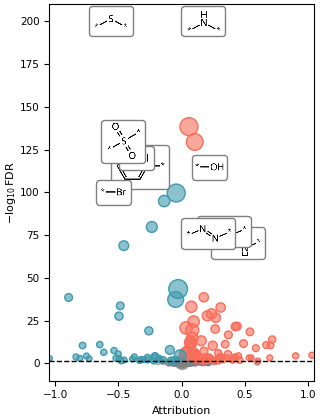

In [5]:
%matplotlib widget

fig, ax = plot_volcano(
    df_stats,
    min_count=10,
    alpha=0.05,
    top_k=5,
    per_direction=True,
    clip_max=200,
    figsize=(3.2, 4.2),
    xlim=(-1.05, 1.05)
)

plt.show()

In [6]:
# plt.savefig(f"output/volcano_{task_name}.pdf")

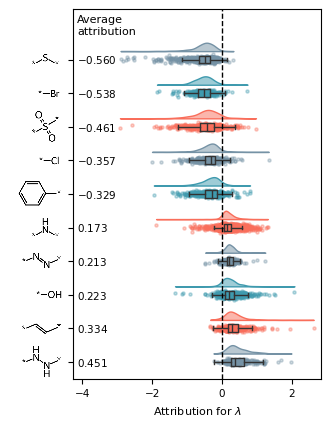

In [ ]:
%matplotlib inline
plt.close('all')

fig, ax = plot_raincloud(
    df_occurrence,
    df_stats,
    top_k=5,
    per_direction=True,
    min_count=10,
    figsize=(3.2, 4.8),
    label=task_name,
)

# plt.savefig(f"output/raincloud_{task_name}.pdf", bbox_inches="tight")
plt.show()